In [1]:
import os
from pathlib import Path
# Ensure CWD is repo root so relative paths and `research.*` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# Statistical Significance Testing via Bootstrap

This notebook evaluates the statistical significance of performance differences between the NER models benchmarked on the `decicontas.br` dataset.

## Methodology

Because the test set contains a limited number of documents, point differences in Span F1 may be sampling artifacts. To quantify metric uncertainty we use **document-level bootstrap** (resampling with replacement), which is:

1. Non-parametric (makes no distributional assumption about the data);
2. Preserves the internal correlation among spans from the same document;
3. Allows us to build confidence intervals (CI) and run paired tests between models.

## Structure

1. Loading predictions for every model;
2. Pre-computing TP/FP/FN per document (greedy matching by descending IoU, IoU $\geq$ 0.5);
3. Individual bootstrap: 95% CI for Span F1 per model (10,000 resamples);
4. Paired bootstrap: 95% CI and *p-value* for the difference between pairs of models;
5. Visualisations (forest plot and heatmap of paired differences);
6. Automatic generation of LaTeX tables ready for the results chapter.


## 1. Configuration and imports

In [2]:
import os
import json
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Global configuration ----
DATA_DIR        = Path("dataset/results/output")
FIG_DIR         = Path("figures")
OUT_DIR         = Path("dataset/experiments/significance_outputs")
N_BOOTSTRAP     = 10_000
SEED            = 42
IOU_THRESHOLD   = 0.5
ALPHA           = 0.05  # significance level (95% CI)

FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# ---- Model list (exactly as they appear in fewshot_results.md) ----
MODELS = [
    "gpt-4-turbo",
    "gpt-5.4-mini_few_shot",
    "gpt-4o",
    "gpt-5.4-nano_few_shot",
    "rufimelo_Legal-BERTimbau-base__supervised",
    "gpt-41-mini",
    "neuralmind_bert-base-portuguese-cased__supervised",
    "gpt-35",
    "gpt-41",
    "neuralmind_bert-large-portuguese-cased__supervised",
    "gemini-2.5-flash_few_shot",
    "deepseek-v3_few_shot",
    "bilstm-crf__supervised",
    "gpt-41-nano",
]

# Display names for tables/figures
DISPLAY_NAMES = {
    "gpt-4-turbo": "GPT-4 Turbo",
    "gpt-5.4-mini_few_shot": "GPT-5.4-mini",
    "gpt-4o": "GPT-4o",
    "gpt-5.4-nano_few_shot": "GPT-5.4-nano",
    "rufimelo_Legal-BERTimbau-base__supervised": "Legal-BERTimbau-base",
    "gpt-41-mini": "GPT-4.1-mini",
    "neuralmind_bert-base-portuguese-cased__supervised": "BERTimbau-base",
    "gpt-35": "GPT-3.5",
    "gpt-41": "GPT-4.1",
    "neuralmind_bert-large-portuguese-cased__supervised": "BERTimbau-large",
    "gemini-2.5-flash_few_shot": "Gemini-2.5-flash",
    "deepseek-v3_few_shot": "DeepSeek-V3",
    "bilstm-crf__supervised": "BiLSTM-CRF",
    "gpt-41-nano": "GPT-4.1-nano",
}

print(f"Bootstrap: {N_BOOTSTRAP:,} resamples | IoU >= {IOU_THRESHOLD} | alpha = {ALPHA}")
print(f"Models to evaluate: {len(MODELS)}")


Bootstrap: 10,000 resamples | IoU >= 0.5 | alpha = 0.05
Models to evaluate: 14


## 2. Loading the data

Two prediction-file layouts coexist in this project, and the loader detects and normalises both:

**LLM layout** (one JSON record per document — used by GPT, Gemini, DeepSeek):
- `text` — raw document;
- `golden` — list of `{start, end, labels}` span dicts;
- `pred` — Pydantic-style dict `{multas: [...], obrigacoes: [...], ...}` — converted on-the-fly to `pred_as_golden` via fuzzy text alignment;
- `pred_as_golden` — same schema as `golden` (used if already present).

**BIO layout** (one JSON record containing parallel label lists — used by BERT/BiLSTM supervised models):
- `true_labels[i]` — list of BIO tags for document *i*;
- `pred_labels[i]` — list of BIO tags predicted for document *i*;
- spans are reconstructed from the BIO sequence; token indices are used as offsets (span-level IoU is unit-free, so this does not affect the metric).

Since every file covers the **same 866 documents in the same order**, alignment is positional — we do not match documents by `text` or `index`.


In [3]:
from rapidfuzz import fuzz

# Mapping from the Pydantic prediction keys to the label names used in `golden`
DICT_LABELS = {
    "obrigacoes":     "OBRIGACAO",
    "recomendacoes":  "RECOMENDACAO",
    "ressarcimentos": "RESSARCIMENTO",
    "multas":         "MULTA",
}


def convert_pred_to_golden_format(row, window_size=500, step_size=100, min_score=80):
    '''
    LLM layout helper: aligns a Pydantic prediction back to character offsets
    in the original text via a sliding-window fuzzy search.
    Returns a list of {'start', 'end', 'text', 'labels'} dicts.
    '''
    pred_spans = []
    text = row["text"]
    pred = row["pred"]
    if not isinstance(pred, dict):
        return pred_spans

    for label_type, spans in pred.items():
        if label_type not in DICT_LABELS or not spans:
            continue
        for span in spans:
            if not isinstance(span, dict):
                continue
            span_text = (span.get("descricao_multa")
                         or span.get("descricao_obrigacao")
                         or span.get("descricao_ressarcimento")
                         or span.get("descricao_recomendacao"))
            if not span_text:
                continue

            best_score, best_pos, best_substring = 0, -1, ""
            for start in range(0, max(1, len(text) - 1), step_size):
                window = text[start:start + window_size]
                score = fuzz.partial_ratio(span_text, window)
                if score > best_score and score >= min_score:
                    best_score = score
                    tokens = span_text.split()
                    if tokens:
                        rel = window.find(tokens[0])
                        best_pos = start + rel if rel >= 0 else start
                    else:
                        best_pos = start
                    best_substring = span_text

            if best_score >= min_score and best_pos >= 0:
                pred_spans.append({
                    "start":  int(best_pos),
                    "end":    int(best_pos + len(best_substring)),
                    "text":   best_substring,
                    "labels": [DICT_LABELS[label_type]],
                })
    return pred_spans


def bio_to_spans(bio_seq) -> list:
    '''
    BIO layout helper: converts a sequence like ['O','B-MULTA','I-MULTA','O',...]
    into a list of {'start', 'end', 'labels'} dicts. Uses token indices as
    offsets (start = first B-X token, end = one past last I-X token).
    Follows the standard BIO convention: spans start at a B- tag; stray I-
    tags without a preceding matching B- are ignored (treated as O).
    '''
    spans = []
    i, n = 0, len(bio_seq)
    while i < n:
        tag = bio_seq[i]
        if isinstance(tag, str) and tag.startswith("B-"):
            label = tag[2:]
            start = i
            i += 1
            while i < n and isinstance(bio_seq[i], str) and bio_seq[i] == f"I-{label}":
                i += 1
            spans.append({"start": start, "end": i, "labels": [label]})
        else:
            i += 1
    return spans


def _candidate_paths(model_name: str) -> list:
    '''Alternative paths where the predictions file may live.'''
    return [
        DATA_DIR / f"models_results_decicontas_{model_name}.json",
        DATA_DIR / f"{model_name}.json",
        DATA_DIR / f"{model_name}_predictions.json",
    ]


def _load_from_llm_layout(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    '''Normalise the GPT/Gemini/DeepSeek layout. Auto-converts pred -> pred_as_golden.'''
    if "pred_as_golden" not in df.columns:
        if "pred" not in df.columns:
            raise ValueError("LLM layout missing both 'pred_as_golden' and 'pred'.")
        print(f"     converting 'pred' -> 'pred_as_golden' for {model_name}...")
        df = df.copy()
        df["pred_as_golden"] = df.apply(convert_pred_to_golden_format, axis=1)
    df["model"] = model_name
    return df.reset_index(drop=True)


def _load_from_bio_layout(obj, model_name: str) -> pd.DataFrame:
    '''
    Normalise the BERT/BiLSTM layout: a JSON holding a single record with
    parallel lists `true_labels` and `pred_labels`, one entry per document.
    Builds a DataFrame with `golden` and `pred_as_golden` derived from BIO tags.
    '''
    rec = obj[0] if isinstance(obj, list) else obj
    true_labels = rec["true_labels"]
    pred_labels = rec["pred_labels"]
    if len(true_labels) != len(pred_labels):
        raise ValueError("BIO layout: true_labels and pred_labels have different lengths.")

    rows = []
    for i, (tl, pl) in enumerate(zip(true_labels, pred_labels)):
        rows.append({
            "doc_id":          i,
            "golden":          bio_to_spans(tl),
            "pred_as_golden":  bio_to_spans(pl),
            "model":           model_name,
        })
    return pd.DataFrame(rows)


def load_model_predictions(model_name: str) -> pd.DataFrame:
    '''
    Loads one model's predictions and returns a DataFrame with at least
    `golden` and `pred_as_golden` columns. Auto-detects the layout.
    '''
    for path in _candidate_paths(model_name):
        if not path.exists():
            continue

        with open(path, "r", encoding="utf-8") as f:
            raw = json.load(f)

        # BIO layout: a single record with 'true_labels' / 'pred_labels' lists
        if isinstance(raw, list) and len(raw) == 1 and isinstance(raw[0], dict) \
                and "true_labels" in raw[0] and "pred_labels" in raw[0]:
            return _load_from_bio_layout(raw, model_name)

        if isinstance(raw, dict) and "true_labels" in raw and "pred_labels" in raw:
            return _load_from_bio_layout(raw, model_name)

        # LLM layout: list of per-document records
        df = pd.DataFrame(raw)
        if {"golden"} <= set(df.columns):
            return _load_from_llm_layout(df, model_name)

        raise ValueError(f"Unrecognised layout in {path}. Columns: {list(df.columns)}")

    raise FileNotFoundError(
        f"No predictions file found for '{model_name}'. "
        f"Tried: {[str(p) for p in _candidate_paths(model_name)]}"
    )


model_dfs = {}
skipped = []
for m in MODELS:
    try:
        model_dfs[m] = load_model_predictions(m)
        print(f"  [OK]  {m:55s} {len(model_dfs[m]):4d} documents")
    except FileNotFoundError:
        skipped.append(m)
        print(f"  [--]  {m:55s} (file not found, skipping)")

print(f"\nLoaded: {len(model_dfs)}  |  Skipped: {len(skipped)}")


     converting 'pred' -> 'pred_as_golden' for gpt-4-turbo...


  [OK]  gpt-4-turbo                                              866 documents
     converting 'pred' -> 'pred_as_golden' for gpt-5.4-mini_few_shot...


  [OK]  gpt-5.4-mini_few_shot                                    866 documents
     converting 'pred' -> 'pred_as_golden' for gpt-4o...


  [OK]  gpt-4o                                                   866 documents
     converting 'pred' -> 'pred_as_golden' for gpt-5.4-nano_few_shot...


  [OK]  gpt-5.4-nano_few_shot                                    866 documents
  [OK]  rufimelo_Legal-BERTimbau-base__supervised                866 documents
     converting 'pred' -> 'pred_as_golden' for gpt-41-mini...


...

  [OK]  gpt-35                                                   866 documents
     converting 'pred' -> 'pred_as_golden' for gpt-41...


  [OK]  gpt-41                                                   866 documents
  [OK]  neuralmind_bert-large-portuguese-cased__supervised       866 documents
     converting 'pred' -> 'pred_as_golden' for gemini-2.5-flash_few_shot...


  [OK]  gemini-2.5-flash_few_shot                                866 documents
     converting 'pred' -> 'pred_as_golden' for deepseek-v3_few_shot...


  [OK]  deepseek-v3_few_shot                                     866 documents
  [OK]  bilstm-crf__supervised                                   866 documents
     converting 'pred' -> 'pred_as_golden' for gpt-41-nano...


  [OK]  gpt-41-nano                                              866 documents

Loaded: 14  |  Skipped: 0


In [4]:
# ---- Drop leaked few-shot examples from every model's results ----
# These 5 dataset ids are present in `tools/fewshot.py` as exemplos in the
# prompt, so they leak gold information at inference time. We exclude them
# from the evaluation set; positions are stable across all 866-document
# result JSONs (verified empirically). The supervised BIO files share the
# same positional ordering, so we drop the same rows there.
from research.fewshot import FEWSHOT_RESULT_POSITIONS

before = {m: len(df) for m, df in model_dfs.items()}
model_dfs = {
    m: df.drop(index=FEWSHOT_RESULT_POSITIONS, errors="ignore").reset_index(drop=True)
    for m, df in model_dfs.items()
}
after = {m: len(df) for m, df in model_dfs.items()}

dropped_counts = {m: before[m] - after[m] for m in model_dfs}
print(f"Dropping rows at positions {FEWSHOT_RESULT_POSITIONS} (leaked few-shots)")
for m in model_dfs:
    print(f"  {m:<55s} {before[m]} -> {after[m]} (-{dropped_counts[m]})")


Dropping rows at positions [5, 781, 789, 816, 851] (leaked few-shots)
  gpt-4-turbo                                             866 -> 861 (-5)
  gpt-5.4-mini_few_shot                                   866 -> 861 (-5)
  gpt-4o                                                  866 -> 861 (-5)
  gpt-5.4-nano_few_shot                                   866 -> 861 (-5)
  rufimelo_Legal-BERTimbau-base__supervised               866 -> 861 (-5)
  gpt-41-mini                                             866 -> 861 (-5)
  neuralmind_bert-base-portuguese-cased__supervised       866 -> 861 (-5)
  gpt-35                                                  866 -> 861 (-5)
  gpt-41                                                  866 -> 861 (-5)
  neuralmind_bert-large-portuguese-cased__supervised      866 -> 861 (-5)
  gemini-2.5-flash_few_shot                               866 -> 861 (-5)
  deepseek-v3_few_shot                                    866 -> 861 (-5)
  bilstm-crf__supervised                  

In [5]:
# Positional alignment: the files cover the same 866 documents in the same
# order, so document i in every model refers to the same underlying example.
# We do NOT align by 'text' (LLM files and BIO files use different offsets
# and may have minor character differences) nor by 'index' (BIO files do
# not carry one). Row position IS the document id.
if len(model_dfs) < 2:
    raise RuntimeError("At least 2 models must be loaded to run comparisons.")

lengths = {m: len(df) for m, df in model_dfs.items()}
print("Document counts per model:")
for m, n in lengths.items():
    print(f"  {m:<55s} {n:4d}")

# Keep only models matching the most common length (usually 866)
from collections import Counter
most_common_len, _ = Counter(lengths.values()).most_common(1)[0]
aligned = {m: df.reset_index(drop=True) for m, df in model_dfs.items()
           if len(df) == most_common_len}

dropped = [m for m, n in lengths.items() if n != most_common_len]
for m in dropped:
    print(f"  [WARN] {m}: {lengths[m]} docs (!= {most_common_len}), excluded.")

print(f"\nAligned models: {len(aligned)}  |  Documents per model: {most_common_len}")
model_dfs = aligned


Document counts per model:
  gpt-4-turbo                                              861
  gpt-5.4-mini_few_shot                                    861
  gpt-4o                                                   861
  gpt-5.4-nano_few_shot                                    861
  rufimelo_Legal-BERTimbau-base__supervised                861
  gpt-41-mini                                              861
  neuralmind_bert-base-portuguese-cased__supervised        861
  gpt-35                                                   861
  gpt-41                                                   861
  neuralmind_bert-large-portuguese-cased__supervised       861
  gemini-2.5-flash_few_shot                                861
  deepseek-v3_few_shot                                     861
  bilstm-crf__supervised                                   861
  gpt-41-nano                                              861

Aligned models: 14  |  Documents per model: 861


## 3. Pre-computing TP / FP / FN per document

To make the bootstrap efficient, we pre-compute once — for each model and each document — the per-document counts that the bootstrap will sum at every iteration. The counting follows the **same non-bipartite scheme used by `calculate_metrics`** in the original evaluation pipeline that produced Table 5.1 of the dissertation:

- A *match* is any `(pred_span, gold_span)` pair with the same label and IoU $\geq 0.5$.
- One predicted span may match multiple gold spans (and vice versa); both pairs are counted.
- Per-document we record `tp[i] = number of matches`, `fp[i] = number_of_predicted_spans - tp[i]`, `fn[i] = number_of_gold_spans - tp[i]`.

This formulation may yield negative `fp[i]` or `fn[i]` for individual documents that contain multi-matches, but the **aggregate** sums are well-behaved: `sum(tp) + sum(fp)` is always the total number of predicted spans, and `sum(tp) + sum(fn)` is the total number of gold spans. Consequently `f1_from_sums(sum(tp), sum(fp), sum(fn))` reproduces exactly the corpus-level F1 of the original evaluation.

This is essential for the bootstrap to be **comparable** to the F1 values reported in Table 5.1: a bipartite (greedy) matching would systematically underestimate F1 for LLM models — whose fuzzy-aligned predictions occasionally produce overlapping spans against the same gold — while leaving supervised BIO-tagged models unaffected. Such a mismatch would invalidate paired comparisons across paradigms.

At each bootstrap iteration we simply sum the pre-computed counts over the resampled set of documents — an $O(n)$ operation per iteration instead of $O(n^2)$.


In [6]:
def compute_doc_level_counts(df: pd.DataFrame, iou_threshold: float = IOU_THRESHOLD):
    '''
    Per-document counts compatible with the aggregate F1 produced by the
    original `calculate_metrics` (Section 5.2).

    Matching is NON-BIPARTITE: every (pred, gold) pair with the same label
    and IoU >= threshold is counted as a match, even if the same prediction
    or gold span participates in multiple matches.

    Returns three numpy arrays of shape (n_docs,):
      tp[i] = number of matching (pred, gold) pairs in document i
      fp[i] = number_of_predicted_spans[i] - tp[i]   (may be negative)
      fn[i] = number_of_gold_spans[i] - tp[i]        (may be negative)

    The negative values are harmless for the bootstrap because only sums
    enter f1_from_sums, and:
      sum(tp + fp) == total predicted spans   (always >= 0)
      sum(tp + fn) == total gold spans        (always >= 0)
    so the recovered precision and recall are identical to those of
    `calculate_metrics`.
    '''
    n = len(df)
    tp = np.zeros(n, dtype=np.int32)
    fp = np.zeros(n, dtype=np.int32)
    fn = np.zeros(n, dtype=np.int32)

    for i, row in enumerate(df.itertuples(index=False)):
        gold = [(g["start"], g["end"], g["labels"][0]) for g in row.golden]
        pred = [(p["start"], p["end"], p["labels"][0]) for p in row.pred_as_golden]

        matches = 0
        for ps in pred:
            for gs in gold:
                if ps[2] != gs[2]:
                    continue
                inter = max(0, min(ps[1], gs[1]) - max(ps[0], gs[0]))
                union = max(ps[1], gs[1]) - min(ps[0], gs[0])
                iou = inter / union if union > 0 else 0.0
                if iou >= iou_threshold:
                    matches += 1

        tp[i] = matches
        fp[i] = len(pred) - matches
        fn[i] = len(gold) - matches

    return tp, fp, fn


def f1_from_sums(tp_sum: int, fp_sum: int, fn_sum: int) -> tuple:
    '''Precision, recall and F1 from aggregated counts. Mirrors the corpus-level
    aggregation used in calculate_metrics: P = tp / (tp + fp), R = tp / (tp + fn).'''
    p = tp_sum / (tp_sum + fp_sum) if (tp_sum + fp_sum) > 0 else 0.0
    r = tp_sum / (tp_sum + fn_sum) if (tp_sum + fn_sum) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    return p, r, f1


# Pre-compute per-document counts for every model
model_counts = {}
multi_match_summary = []
print(f"{'Model':<55s} {'Span F1':>8s} {'Prec':>8s} {'Rec':>8s} {'multi-match':>12s}")
print("-" * 100)
for m, df in model_dfs.items():
    tp, fp, fn = compute_doc_level_counts(df)
    p, r, f1 = f1_from_sums(int(tp.sum()), int(fp.sum()), int(fn.sum()))
    # Count documents where a span matched more than one counterpart
    n_multi = int(((fp < 0) | (fn < 0)).sum())
    model_counts[m] = {"tp": tp, "fp": fp, "fn": fn, "f1": f1, "p": p, "r": r}
    multi_match_summary.append((m, n_multi))
    print(f"{m:<55s} {f1:>8.4f} {p:>8.4f} {r:>8.4f} {n_multi:>12d}")

print()
print("multi-match = number of documents where a single pred or gold span")
print("              matched more than one counterpart (causing fp or fn < 0)."
)
print("              Supervised BIO models always show 0 because BIO outputs")
print("              do not produce overlapping spans by construction.")


Model                                                    Span F1     Prec      Rec  multi-match
----------------------------------------------------------------------------------------------------
gpt-4-turbo                                               0.7737   0.6976   0.8685            1
gpt-5.4-mini_few_shot                                     0.7689   0.7053   0.8451            0
gpt-4o                                                    0.7611   0.6874   0.8526            0
gpt-5.4-nano_few_shot                                     0.7623   0.6927   0.8474            0
rufimelo_Legal-BERTimbau-base__supervised                 0.6388   0.7985   0.5323            0
gpt-41-mini                                               0.7437   0.6679   0.8390            0
neuralmind_bert-base-portuguese-cased__supervised         0.7080   0.7932   0.6393            0
gpt-35                                                    0.7376   0.6667   0.8254            0
gpt-41                             

## 4. Individual bootstrap — 95% Confidence Intervals

For each model we resample the test-set documents with replacement $B = 10{,}000$ times. In every resample we compute Span F1, and at the end we take the $2.5\%$ and $97.5\%$ percentiles as the CI boundaries.


In [7]:
def bootstrap_ci_f1(counts: dict,
                    n_iter: int = N_BOOTSTRAP,
                    seed: int = SEED,
                    alpha: float = ALPHA) -> dict:
    '''Document-level bootstrap. Returns mean, std, CI and full distribution.'''
    tp, fp, fn = counts["tp"], counts["fp"], counts["fn"]
    n = len(tp)
    rng = np.random.default_rng(seed)

    f1s = np.empty(n_iter, dtype=np.float64)
    # Vectorised: sample all indices at once and loop
    idx_matrix = rng.integers(0, n, size=(n_iter, n))
    for b in range(n_iter):
        idx = idx_matrix[b]
        tp_s = tp[idx].sum()
        fp_s = fp[idx].sum()
        fn_s = fn[idx].sum()
        _, _, f1 = f1_from_sums(tp_s, fp_s, fn_s)
        f1s[b] = f1

    lo = np.percentile(f1s, 100 * alpha / 2)
    hi = np.percentile(f1s, 100 * (1 - alpha / 2))
    return {
        "mean": float(f1s.mean()),
        "std":  float(f1s.std(ddof=1)),
        "ci_lower": float(lo),
        "ci_upper": float(hi),
        "samples": f1s,
    }


results_ci = {}
for m, counts in model_counts.items():
    results_ci[m] = bootstrap_ci_f1(counts)

df_ci = pd.DataFrame([
    {
        "model":         m,
        "display_name":  DISPLAY_NAMES.get(m, m),
        "span_f1_point": model_counts[m]["f1"],  # point F1 (no bootstrap)
        "span_f1_mean":  r["mean"],
        "std":           r["std"],
        "ci_lower":      r["ci_lower"],
        "ci_upper":      r["ci_upper"],
        "ci_width":      r["ci_upper"] - r["ci_lower"],
    }
    for m, r in results_ci.items()
]).sort_values("span_f1_point", ascending=False).reset_index(drop=True)

df_ci.round(4)


,model,display_name,span_f1_point,span_f1_mean,std,ci_lower,ci_upper,ci_width
0,gpt-4-turbo,GPT-4 Turbo,0.7737,0.7735,0.0200,0.7325,0.8115,0.0790
1,gpt-5.4-mini_few_shot,GPT-5.4-mini,0.7689,0.7689,0.0219,0.7247,0.8105,0.0858
2,gpt-5.4-nano_few_shot,GPT-5.4-nano,0.7623,0.7621,0.0215,0.7193,0.8027,0.0834
3,gpt-4o,GPT-4o,0.7611,0.7610,0.0216,0.7174,0.8018,0.0843
4,gpt-41-mini,GPT-4.1-mini,0.7437,0.7434,0.0214,0.6999,0.7844,0.0845
5,gpt-35,GPT-3.5,0.7376,0.7372,0.0224,0.6912,0.7798,0.0886
6,gpt-41,GPT-4.1,0.7333,0.7329,0.0205,0.6914,0.7721,0.0807
7,bilstm-crf__supervised,BiLSTM-CRF,0.7257,0.7254,0.0238,0.6779,0.7706,0.0927
8,gemini-2.5-flash_few_shot,Gemini-2.5-flash,0.7141,0.7138,0.0201,0.6730,0.7522,0.0791
9,neuralmind_bert-base-portuguese-cased__supervised,BERTimbau-base,0.7080,0.7075,0.0243,0.6575,0.7539,0.0964


## 5. Paired bootstrap — differences between models

To test $H_0: F1_A = F1_B$ against $H_1: F1_A \neq F1_B$ non-parametrically:

1. At each iteration $b$, draw a single set of document indices $I_b$;
2. Compute $F1_A(I_b)$ and $F1_B(I_b)$ **on the same resample** (pairing by document reduces variance);
3. Record $\Delta_b = F1_A(I_b) - F1_B(I_b)$;
4. The distribution $\{\Delta_b\}_{b=1}^{B}$ gives a 95% CI for the difference;
5. The two-sided *p-value* is estimated as $2 \cdot \min\{P(\Delta \leq 0),\ P(\Delta \geq 0)\}$.

If the 95% CI **does not contain zero**, the difference is significant at the 5% level.


In [8]:
def paired_bootstrap_diff(counts_a: dict,
                          counts_b: dict,
                          n_iter: int = N_BOOTSTRAP,
                          seed: int = SEED,
                          alpha: float = ALPHA) -> dict:
    '''Paired bootstrap for F1_A - F1_B on the SAME resampled documents.'''
    n = len(counts_a["tp"])
    assert n == len(counts_b["tp"]), "Models must have the same number of documents."

    rng = np.random.default_rng(seed)
    idx_matrix = rng.integers(0, n, size=(n_iter, n))

    diffs = np.empty(n_iter, dtype=np.float64)
    for b in range(n_iter):
        idx = idx_matrix[b]
        _, _, f1_a = f1_from_sums(
            counts_a["tp"][idx].sum(),
            counts_a["fp"][idx].sum(),
            counts_a["fn"][idx].sum(),
        )
        _, _, f1_b = f1_from_sums(
            counts_b["tp"][idx].sum(),
            counts_b["fp"][idx].sum(),
            counts_b["fn"][idx].sum(),
        )
        diffs[b] = f1_a - f1_b

    lo = float(np.percentile(diffs, 100 * alpha / 2))
    hi = float(np.percentile(diffs, 100 * (1 - alpha / 2)))

    # Two-sided p-value (proportion of diffs on the opposite side of the mean's sign)
    p_two_sided = 2 * min((diffs <= 0).mean(), (diffs >= 0).mean())
    p_two_sided = float(min(p_two_sided, 1.0))

    return {
        "mean_diff": float(diffs.mean()),
        "ci_lower":  lo,
        "ci_upper":  hi,
        "p_value":   p_two_sided,
        "significant": (lo > 0) or (hi < 0),
    }


# Run all pairs (C(n,2) = n(n-1)/2 combinations)
model_list = list(model_counts.keys())
n_pairs = len(model_list) * (len(model_list) - 1) // 2
print(f"Computing {n_pairs} paired comparisons...")

pair_rows = []
for a, b in combinations(model_list, 2):
    r = paired_bootstrap_diff(model_counts[a], model_counts[b])
    pair_rows.append({
        "model_a":        a,
        "model_b":        b,
        "display_a":      DISPLAY_NAMES.get(a, a),
        "display_b":      DISPLAY_NAMES.get(b, b),
        "f1_a":           model_counts[a]["f1"],
        "f1_b":           model_counts[b]["f1"],
        "diff_f1":        r["mean_diff"],
        "ci_lower":       r["ci_lower"],
        "ci_upper":       r["ci_upper"],
        "p_value":        r["p_value"],
        "significant_95": r["significant"],
    })

df_pairs = (pd.DataFrame(pair_rows)
            .sort_values("diff_f1", key=abs, ascending=False)
            .reset_index(drop=True))
print(f"Total pairs: {len(df_pairs)} | Significant at 5%: {df_pairs['significant_95'].sum()}")
df_pairs.head(15).round(4)

df_pairs.to_markdown(OUT_DIR / "paired_bootstrap_results.csv", index=False)


Computing 91 paired comparisons...


Total pairs: 91 | Significant at 5%: 52


### 5.1. Pairs relevant to the chapter's narrative

We highlight the comparisons referenced directly in the dissertation text:

- **GPT-4 Turbo vs. GPT-5.4-mini** — tests whether the top of the ranking is statistically indistinguishable (the "saturation" hypothesis);
- **GPT-4 Turbo vs. GPT-4o** — same check for the top-three;
- **Best few-shot vs. best supervised** — confirms whether the Span F1 gain of LLMs over fine-tuned models is real;
- **GPT-4.1-nano vs. the rest** — confirms the degradation of the lowest-capacity model.


In [9]:
highlighted_pairs = [
    ("gpt-4-turbo",                 "gpt-5.4-mini_few_shot"),
    ("gpt-4-turbo",                 "gpt-4o"),
    ("gpt-5.4-mini_few_shot",       "gpt-4o"),
    ("gpt-4-turbo",                 "rufimelo_Legal-BERTimbau-base__supervised"),
    ("gpt-4-turbo",                 "neuralmind_bert-base-portuguese-cased__supervised"),
    ("gpt-5.4-mini_few_shot",       "rufimelo_Legal-BERTimbau-base__supervised"),
    ("gpt-4-turbo",                 "gpt-41-nano"),
    ("gpt-4-turbo",                 "deepseek-v3_few_shot"),
    ("gpt-4-turbo",                 "gemini-2.5-flash_few_shot"),
]

mask = df_pairs.apply(
    lambda row: ((row["model_a"], row["model_b"]) in highlighted_pairs
                 or (row["model_b"], row["model_a"]) in highlighted_pairs),
    axis=1,
)
df_highlighted = df_pairs[mask].copy().reset_index(drop=True)
df_highlighted[["display_a", "display_b", "f1_a", "f1_b",
                "diff_f1", "ci_lower", "ci_upper",
                "p_value", "significant_95"]].round(4)


,display_a,display_b,f1_a,f1_b,diff_f1,ci_lower,ci_upper,p_value,significant_95
0,GPT-4 Turbo,GPT-4.1-nano,0.7737,0.4494,0.3246,0.2806,0.3694,0.0000,True
1,GPT-4 Turbo,Legal-BERTimbau-base,0.7737,0.6388,0.1352,0.0831,0.1884,0.0000,True
2,GPT-5.4-mini,Legal-BERTimbau-base,0.7689,0.6388,0.1306,0.0749,0.1856,0.0000,True
3,GPT-4 Turbo,DeepSeek-V3,0.7737,0.6756,0.0983,0.0616,0.1356,0.0000,True
4,GPT-4 Turbo,BERTimbau-base,0.7737,0.7080,0.0660,0.0190,0.1128,0.0056,True
5,GPT-4 Turbo,Gemini-2.5-flash,0.7737,0.7141,0.0597,0.0282,0.0915,0.0002,True
6,GPT-4 Turbo,GPT-4o,0.7737,0.7611,0.0126,-0.0202,0.0465,0.4568,False
7,GPT-5.4-mini,GPT-4o,0.7689,0.7611,0.0079,-0.0229,0.0394,0.6190,False
8,GPT-4 Turbo,GPT-5.4-mini,0.7737,0.7689,0.0046,-0.0352,0.0461,0.8352,False


## 6. Visualisations

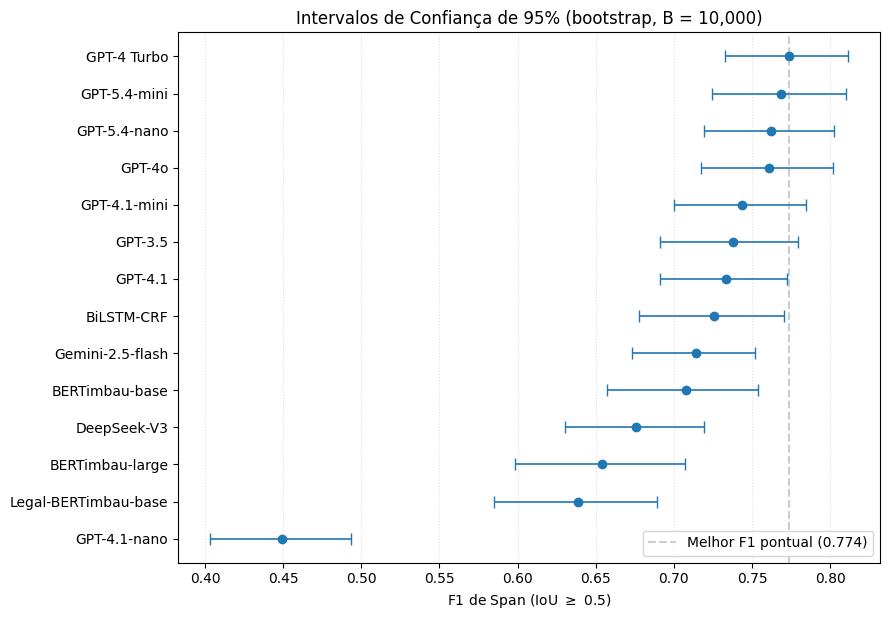

In [10]:
# ---- Forest plot: per-model 95% CI ----
plt.rcParams.update({"font.size": 10})

df_plot = df_ci.sort_values("span_f1_point").reset_index(drop=True)
y = np.arange(len(df_plot))

fig, ax = plt.subplots(figsize=(9, max(4, 0.45 * len(df_plot))))
ax.errorbar(
    df_plot["span_f1_point"], y,
    xerr=[df_plot["span_f1_point"] - df_plot["ci_lower"],
          df_plot["ci_upper"]      - df_plot["span_f1_point"]],
    fmt="o", capsize=4, markersize=6, linewidth=1.2,
)
# Reference line at the best model
best_f1 = df_plot["span_f1_point"].max()
ax.axvline(best_f1, color="gray", linestyle="--", alpha=0.4,
           label=f"Melhor F1 pontual ({best_f1:.3f})")

ax.set_yticks(y)
ax.set_yticklabels(df_plot["display_name"])
ax.set_xlabel("F1 de Span (IoU $\\geq$ 0.5)")
ax.set_title(f"Intervalos de Confiança de 95% (bootstrap, B = {N_BOOTSTRAP:,})")
ax.grid(axis="x", linestyle=":", alpha=0.4)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIG_DIR / "forest_plot_bootstrap.png", bbox_inches="tight", dpi=160)
plt.show()


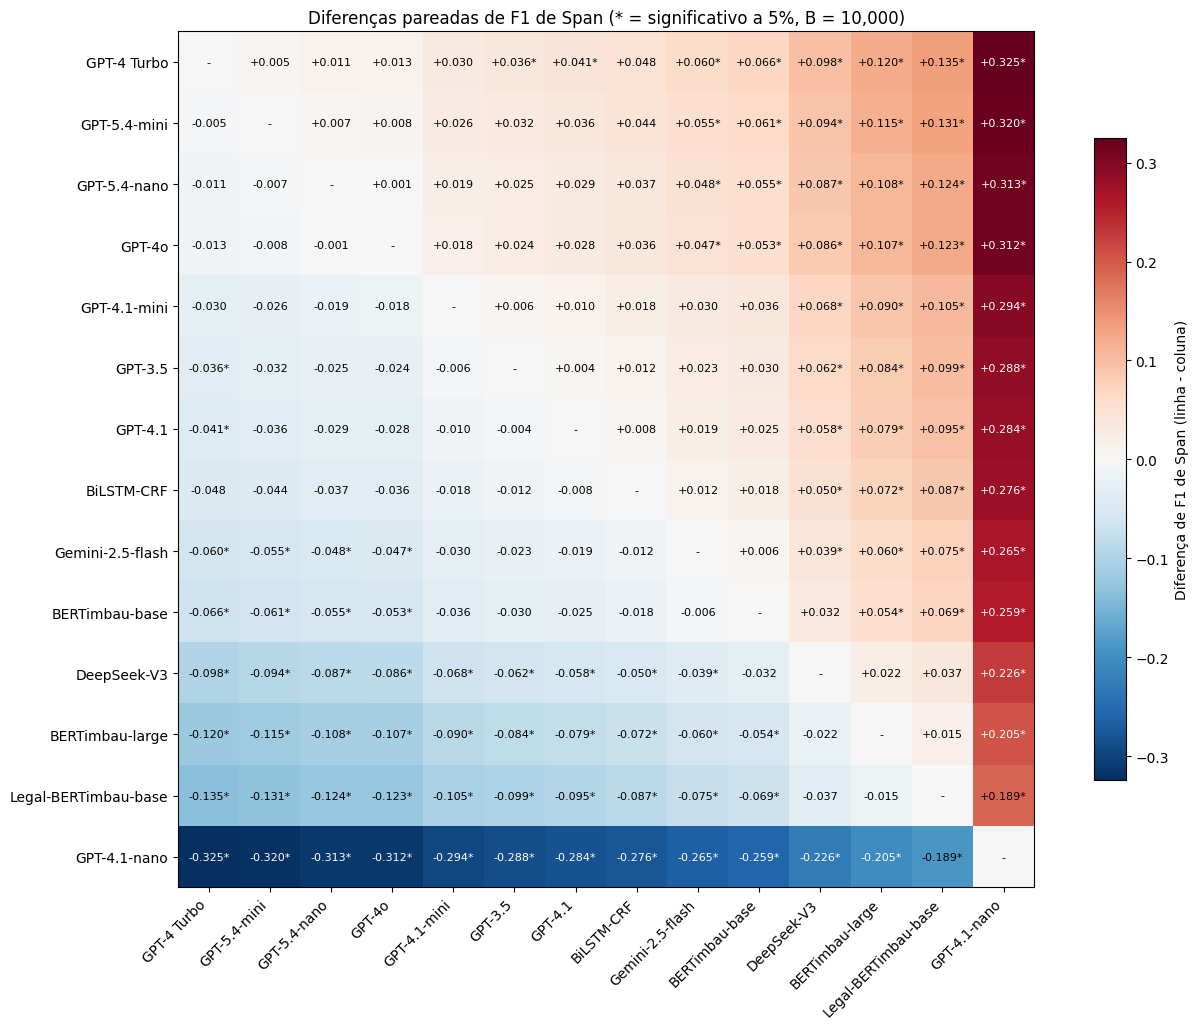

In [11]:
# ---- Heatmap of paired differences ----
model_order = df_ci["model"].tolist()            # best to worst
display_order = [DISPLAY_NAMES.get(m, m) for m in model_order]
n = len(model_order)
diff_mat = np.zeros((n, n))
sig_mat  = np.zeros((n, n), dtype=bool)

idx = {m: i for i, m in enumerate(model_order)}
for _, row in df_pairs.iterrows():
    i = idx[row["model_a"]]; j = idx[row["model_b"]]
    diff_mat[i, j] =  row["diff_f1"]
    diff_mat[j, i] = -row["diff_f1"]
    sig_mat[i, j]  = row["significant_95"]
    sig_mat[j, i]  = row["significant_95"]

# Cell annotations: difference with asterisk if significant
annot = np.empty_like(diff_mat, dtype=object)
for i in range(n):
    for j in range(n):
        if i == j:
            annot[i, j] = "-"
        else:
            s = f"{diff_mat[i, j]:+.3f}"
            if sig_mat[i, j]:
                s += "*"
            annot[i, j] = s

fig, ax = plt.subplots(figsize=(0.75 * n + 3, 0.6 * n + 2))
vmax = np.abs(diff_mat).max()
im = ax.imshow(diff_mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="equal")

ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(display_order, rotation=45, ha="right")
ax.set_yticklabels(display_order)

for i in range(n):
    for j in range(n):
        color = "black" if abs(diff_mat[i, j]) < 0.6 * vmax else "white"
        ax.text(j, i, annot[i, j], ha="center", va="center", color=color, fontsize=8)

cbar = plt.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label("Diferença de F1 de Span (linha - coluna)")
ax.set_title(f"Diferenças pareadas de F1 de Span (* = significativo a 5%, B = {N_BOOTSTRAP:,})")
plt.tight_layout()
plt.savefig(FIG_DIR / "heatmap_pairs_bootstrap.png", bbox_inches="tight", dpi=160)
plt.show()


## 7. Export — CSVs and LaTeX tables

In [12]:
# CSVs with the full results
df_ci.to_csv(OUT_DIR / "bootstrap_ci.csv", index=False, encoding="utf-8")
df_pairs.to_csv(OUT_DIR / "bootstrap_paired.csv", index=False, encoding="utf-8")
df_highlighted.to_csv(OUT_DIR / "bootstrap_highlighted_pairs.csv", index=False, encoding="utf-8")
print(f"CSVs saved to {OUT_DIR.resolve()}")


CSVs saved to /Users/eduardo/Dev/decicontas.br/dataset/experiments/significance_outputs


In [13]:
# ---- LaTeX table of individual CIs (ready for the chapter) ----
def escape_latex(s: str) -> str:
    return (s.replace("\\", r"\textbackslash{}")
             .replace("&", r"\&")
             .replace("%", r"\%")
             .replace("_", r"\_")
             .replace("#", r"\#"))

lines_ic = []
for _, row in df_ci.iterrows():
    name = escape_latex(row["display_name"])
    lines_ic.append(
        f"        {name:<35s} & {row['span_f1_point']:.4f} "
        f"& [{row['ci_lower']:.3f};\\ {row['ci_upper']:.3f}] \\\\"
    )

latex_ci = (
    "\\begin{table}[ht]\n"
    "    \\centering\n"
    "    \\caption{95\\% confidence intervals via \\textit{bootstrap} "
    "for the Span F1 of every evaluated model ("
    f"{N_BOOTSTRAP:,} document-level resamples, IoU $\\geq$ 0.5).}}\n"
    "    \\label{tab:bootstrap_ic}\n"
    "    \\small\n"
    "    \\begin{tabular}{lcc}\n"
    "        \\hline\n"
    "        \\textbf{Model} & \\textbf{Span F1} & \\textbf{95\\% CI} \\\\\n"
    "        \\hline\n"
    + "\n".join(lines_ic) + "\n"
    "        \\hline\n"
    "    \\end{tabular}\n"
    "\\end{table}\n"
)

with open(OUT_DIR / "table_bootstrap_ic.tex", "w", encoding="utf-8") as f:
    f.write(latex_ci)

print(latex_ci)


\begin{table}[ht]
    \centering
    \caption{95\% confidence intervals via \textit{bootstrap} for the Span F1 of every evaluated model (10,000 document-level resamples, IoU $\geq$ 0.5).}
    \label{tab:bootstrap_ic}
    \small
    \begin{tabular}{lcc}
        \hline
        \textbf{Model} & \textbf{Span F1} & \textbf{95\% CI} \\
        \hline
        GPT-4 Turbo                         & 0.7737 & [0.733;\ 0.812] \\
        GPT-5.4-mini                        & 0.7689 & [0.725;\ 0.810] \\
        GPT-5.4-nano                        & 0.7623 & [0.719;\ 0.803] \\
        GPT-4o                              & 0.7611 & [0.717;\ 0.802] \\
        GPT-4.1-mini                        & 0.7437 & [0.700;\ 0.784] \\
        GPT-3.5                             & 0.7376 & [0.691;\ 0.780] \\
        GPT-4.1                             & 0.7333 & [0.691;\ 0.772] \\
        BiLSTM-CRF                          & 0.7257 & [0.678;\ 0.771] \\
        Gemini-2.5-flash                    & 0.7141 & [0.673

In [14]:
# ---- LaTeX table of highlighted paired comparisons ----
lines_pairs = []
for _, row in df_highlighted.iterrows():
    a = escape_latex(row["display_a"])
    b = escape_latex(row["display_b"])
    sig = "Yes" if row["significant_95"] else "No"
    # Scientific notation for very small p-values
    if row["p_value"] < 1e-3:
        p_str = "$< 0.001$"
    else:
        p_str = f"{row['p_value']:.3f}"
    diff_str = f"{row['diff_f1']:+.3f}"
    ci_str = f"[{row['ci_lower']:+.3f};\\ {row['ci_upper']:+.3f}]"
    lines_pairs.append(
        f"        {a} vs. {b} & {diff_str} & {ci_str} & {p_str} & {sig} \\\\"
    )

latex_pairs = (
    "\\begin{table}[ht]\n"
    "    \\centering\n"
    "    \\caption{Paired comparisons via \\textit{bootstrap} "
    f"(B = {N_BOOTSTRAP:,}). "
    "A positive $\\Delta$ Span F1 indicates that the first model outperforms the second.}\n"
    "    \\label{tab:bootstrap_paired}\n"
    "    \\small\n"
    "    \\begin{tabular}{lcccc}\n"
    "        \\hline\n"
    "        \\textbf{Comparison} & $\\Delta$ \\textbf{F1} "
    "& \\textbf{95\\% CI of difference} & $\\mathbf{p}$ & \\textbf{Sig. 5\\%} \\\\\n"
    "        \\hline\n"
    + "\n".join(lines_pairs) + "\n"
    "        \\hline\n"
    "    \\end{tabular}\n"
    "\\end{table}\n"
)

with open(OUT_DIR / "table_bootstrap_paired.tex", "w", encoding="utf-8") as f:
    f.write(latex_pairs)

print(latex_pairs)


\begin{table}[ht]
    \centering
    \caption{Paired comparisons via \textit{bootstrap} (B = 10,000). A positive $\Delta$ Span F1 indicates that the first model outperforms the second.}
    \label{tab:bootstrap_paired}
    \small
    \begin{tabular}{lcccc}
        \hline
        \textbf{Comparison} & $\Delta$ \textbf{F1} & \textbf{95\% CI of difference} & $\mathbf{p}$ & \textbf{Sig. 5\%} \\
        \hline
        GPT-4 Turbo vs. GPT-4.1-nano & +0.325 & [+0.281;\ +0.369] & $< 0.001$ & Yes \\
        GPT-4 Turbo vs. Legal-BERTimbau-base & +0.135 & [+0.083;\ +0.188] & $< 0.001$ & Yes \\
        GPT-5.4-mini vs. Legal-BERTimbau-base & +0.131 & [+0.075;\ +0.186] & $< 0.001$ & Yes \\
        GPT-4 Turbo vs. DeepSeek-V3 & +0.098 & [+0.062;\ +0.136] & $< 0.001$ & Yes \\
        GPT-4 Turbo vs. BERTimbau-base & +0.066 & [+0.019;\ +0.113] & 0.006 & Yes \\
        GPT-4 Turbo vs. Gemini-2.5-flash & +0.060 & [+0.028;\ +0.091] & $< 0.001$ & Yes \\
        GPT-4 Turbo vs. GPT-4o & +0.013 & [-0.020;\

## 8. Summary for the chapter narrative

The bullets below are generated automatically from the results so that they can be pasted into the Statistical Significance section.


In [15]:
# Programmatic summary for the text
best_row = df_ci.iloc[0]
best_model = best_row["model"]
print(f"- Best model by point Span F1: {best_row['display_name']} "
      f"(F1 = {best_row['span_f1_point']:.4f}, 95% CI = "
      f"[{best_row['ci_lower']:.3f}; {best_row['ci_upper']:.3f}])")

# Models statistically INDISTINGUISHABLE from the best (using the paired test)
# Criterion: the paired comparison was NOT significant at 5%
pairs_with_best = df_pairs[(df_pairs["model_a"] == best_model)
                           | (df_pairs["model_b"] == best_model)].copy()
not_sig = pairs_with_best[~pairs_with_best["significant_95"]]
print(f"\n- Models statistically indistinguishable from the best "
      f"(paired test, {len(not_sig)} models):")
for _, r in not_sig.iterrows():
    other = r["display_b"] if r["model_a"] == best_model else r["display_a"]
    print(f"    * {other:<25s}  Delta F1 = {r['diff_f1']:+.4f}  "
          f"CI [{r['ci_lower']:+.3f}; {r['ci_upper']:+.3f}]  p = {r['p_value']:.3f}")

# Count of significant pairs
n_sig = int(df_pairs["significant_95"].sum())
n_tot = len(df_pairs)
print(f"\n- Pairs with significant difference at 5%: {n_sig}/{n_tot} "
      f"({100*n_sig/n_tot:.1f}%)")

# Smallest and largest significant differences
sig_pairs = df_pairs[df_pairs["significant_95"]].copy()
if len(sig_pairs) > 0:
    sig_pairs["abs_diff"] = sig_pairs["diff_f1"].abs()
    min_sig = sig_pairs.loc[sig_pairs["abs_diff"].idxmin()]
    max_sig = sig_pairs.loc[sig_pairs["abs_diff"].idxmax()]
    print(f"\n- Smallest statistically significant difference: "
          f"{min_sig['display_a']} vs. {min_sig['display_b']} "
          f"(|Delta F1| = {abs(min_sig['diff_f1']):.4f}, p = {min_sig['p_value']:.3f})")
    print(f"- Largest statistically significant difference: "
          f"{max_sig['display_a']} vs. {max_sig['display_b']} "
          f"(|Delta F1| = {abs(max_sig['diff_f1']):.4f}, p = {max_sig['p_value']:.3f})")


- Best model by point Span F1: GPT-4 Turbo (F1 = 0.7737, 95% CI = [0.733; 0.812])

- Models statistically indistinguishable from the best (paired test, 5 models):
    * BiLSTM-CRF                 Delta F1 = +0.0481  CI [-0.001; +0.096]  p = 0.056
    * GPT-4.1-mini               Delta F1 = +0.0302  CI [-0.004; +0.066]  p = 0.090
    * GPT-4o                     Delta F1 = +0.0126  CI [-0.020; +0.046]  p = 0.457
    * GPT-5.4-nano               Delta F1 = +0.0114  CI [-0.019; +0.044]  p = 0.491
    * GPT-5.4-mini               Delta F1 = +0.0046  CI [-0.035; +0.046]  p = 0.835

- Pairs with significant difference at 5%: 52/91 (57.1%)

- Smallest statistically significant difference: GPT-4 Turbo vs. GPT-3.5 (|Delta F1| = 0.0363, p = 0.048)
- Largest statistically significant difference: GPT-4 Turbo vs. GPT-4.1-nano (|Delta F1| = 0.3246, p = 0.000)
